# Fast Extragradient Method (FEG)

We consider a monotone and $L$-Lipschitz operator $A$ with a zero $x_\star$, so $A(x_\star)=0$, and an initial point satisfying $\|x_0-x_\star\|^2 \le R^2$. The performance metric is the squared residual $\|A(x_N)\|^2$.

For $k=0$, the initial point is also tagged as the half-step point, $x_{1/2}=x_0$. For $k \ge 0$, FEG uses
\begin{align*}
x_{k+1/2} &= x_k + \frac{1}{k+1}(x_0-x_k) - \frac{k}{k+1}\frac{1}{L}A(x_k), \\
x_{k+1} &= x_k + \frac{1}{k+1}(x_0-x_k) - \frac{1}{L}A(x_{k+1/2}).
\end{align*}

The numerical PEP evidence below suggests the worst-case value is $2L^2R^2$ at $N=1$ and follows $4L^2R^2/N^2$ for $N \ge 2$.

## Proof Statement

### Theorem

Assume that $A$ is monotone and $L$-Lipschitz, that $A(x_{\star})=0$, and that $\|x_{0}-x_{\star}\|^{2}\le R^{2}$. For the Fast Extragradient iterates defined above and every $N\ge 2$,

$$
\|A(x_{N})\|^{2}\le \frac{4L^{2}R^{2}}{N^{2}}.
$$

A Lyapunov certificate for $1\le k\le N$ is

$$
V_{k}=\frac{2k^{2}}{N^{2}}\|A(x_{k})\|^{2}-\frac{4kL}{N^{2}}\langle A(x_{k}),x_{0}-x_{k}\rangle.
$$

### Proof outline

Let

$$
\operatorname{Lip}(u,v)=\|A(u)-A(v)\|^{2}-L^{2}\|u-v\|^{2}\le 0,
$$

and

$$
\operatorname{Mon}(u,v)=-\langle A(u)-A(v),u-v\rangle\le 0.
$$

The base identity is

$$
V_{1}-V_{0}=\frac{2}{N^{2}}\operatorname{Lip}(x_{0},x_{1})\le 0.
$$

For $1\le k<N$,

$$
V_{k+1}-V_{k}=\frac{2(k+1)^{2}}{N^{2}}\operatorname{Lip}(x_{k+1/2},x_{k+1})+\frac{4k(k+1)L}{N^{2}}\operatorname{Mon}(x_{k},x_{k+1})\le 0.
$$

Thus $V_{N}\le V_{0}=0$. The boundary identity is

$$
\frac{4L^{2}}{N^{2}}\|x_{0}-x_{\star}\|^{2}-\|A(x_{N})\|^{2}+V_{N}+\frac{4L}{N}\operatorname{Mon}(x_{N},x_{\star})-\left\|A(x_{N})-\frac{2L}{N}(x_{0}-x_{\star})\right\|^{2}=0.
$$

Since $V_{N}\le 0$, $\operatorname{Mon}(x_{N},x_{\star})\le 0$, and the square is nonnegative, the claimed residual bound follows.

## Imports

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "feg":
    repo_root = repo_root.parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pepflow as pf  # noqa: E402
import sympy as sp  # noqa: E402

## Operator And Parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
A = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A"], L=L)

## PEP Setup

In [3]:
def make_ctx_feg(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    N_int = int(N)
    ctx = pf.PEPContext(ctx_name).set_as_current()

    x_0 = pf.Vector(is_basis=True, tags=["x_0"])
    x_0.add_tag("x_0.5")
    x = x_0
    A.set_zero_point("x_star")

    for k in range(N_int):
        if k == 0:
            x_half = x_0
        else:
            inv_k_plus_1 = sp.Rational(1, k + 1)
            x_half = (
                x
                + inv_k_plus_1 * (x_0 - x)
                - sp.Rational(k, k + 1) * (sp.S(1) / L) * A(x)
            )
            x_half.add_tag(f"x_{k + 0.5}")

        x = x + sp.Rational(1, k + 1) * (x_0 - x) - (sp.S(1) / L) * A(x_half)
        x.add_tag(f"x_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    ctx = make_ctx_feg(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(A(ctx[f"x_{N}"]) ** 2)
    return ctx, pb, A

## Numerical Evidence

N=1: PEP=2.00001953, candidate=2.00000000
N=2: PEP=0.99999954, candidate=1.00000000
N=3: PEP=0.44444019, candidate=0.44444444
N=4: PEP=0.24999917, candidate=0.25000000
N=5: PEP=0.16001459, candidate=0.16000000
N=6: PEP=0.11111313, candidate=0.11111111
N=7: PEP=0.08164731, candidate=0.08163265


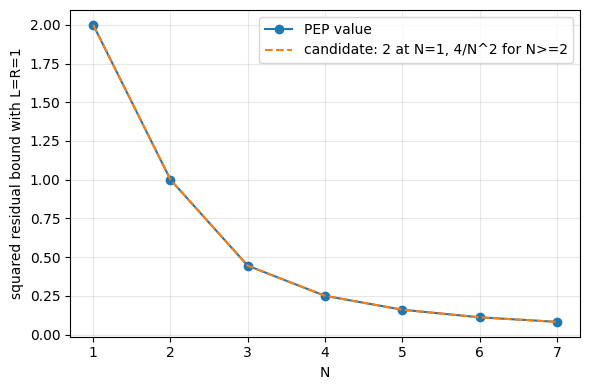

In [4]:
import json

state_path = repo_root / "examples_peppy" / "feg" / "state" / "feg_b1.json"
state = json.loads(state_path.read_text())
results = state["sweep_results"]
N_values = np.array([r["N"] for r in results], dtype=float)
pep_values = np.array([r["opt_value"] for r in results], dtype=float)
rate_guess = np.where(N_values == 1, 2.0, 4.0 / (N_values**2))

for N, value, guess in zip(N_values.astype(int), pep_values, rate_guess):
    print(f"N={N}: PEP={value:.8f}, candidate={guess:.8f}")

plt.figure(figsize=(6, 4))
plt.plot(N_values, pep_values, "o-", label="PEP value")
plt.plot(N_values, rate_guess, "--", label="candidate: 2 at N=1, 4/N^2 for N>=2")
plt.xlabel("N")
plt.ylabel("squared residual bound with L=R=1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

## Candidate Rate

The Block 1 numerical evidence supports
\[
\|A(x_N)\|^2 \le
\begin{cases}
2L^2R^2, & N=1,\\
\frac{4L^2R^2}{N^2}, & N\ge 2.
\end{cases}
\]
The following sections are reserved for the dense and relaxed proof solves, closed-form dual variables, partial-sum Lyapunov construction, special-vector identification, coefficient extraction, and symbolic verification.

## Dense And Relaxed Proof Solves

The dense solve is performed at `N_verify = 4`. The relaxed certificate keeps only the monotone inequalities `(x_i, x_{i+1})` for `1 <= i < N`, the final monotone inequality `(x_N, x_star)`, and the Lipschitz inequalities `(x_{i+1/2}, x_{i+1})` for `0 <= i < N`.

In [5]:
from fractions import Fraction

state_dir = repo_root / "examples_peppy" / "feg" / "state"
dense = json.loads((state_dir / "feg_dense.json").read_text())
relaxed = json.loads((state_dir / "feg_relaxed.json").read_text())
b2 = json.loads((state_dir / "feg_b2.json").read_text())

print(f"Dense objective:   {dense['opt_value']:.10f}")
print(f"Relaxed objective: {relaxed['opt_value']:.10f}")
print(f"Preserved optimum: {abs(dense['opt_value'] - relaxed['opt_value']) < 1e-5}")
print(f"Dropped constraints: {len(b2['relaxed_constraints'])}")
print("Basis vectors:", relaxed["basis_vectors"])

Dense objective:   0.2499991745
Relaxed objective: 0.2500006838
Preserved optimum: True
Dropped constraints: 120
Basis vectors: ['x_0.5', 'x_star', 'A(x_0.5)', 'A(x_1)', 'A(x_1.5)', 'A(x_2)', 'A(x_2.5)', 'A(x_3)', 'A(x_3.5)', 'A(x_4)']


In [6]:
def active_entries(group_data, tol=1e-6):
    matrix = np.array(group_data["matrix"], dtype=float)
    rows = group_data["row_names"]
    cols = group_data["col_names"]
    entries = []
    for i, ri in enumerate(rows):
        for j, ci in enumerate(cols):
            value = matrix[i, j]
            if abs(value) > tol:
                entries.append((ri, ci, value, Fraction(value).limit_denominator(1000)))
    return entries


for group, group_data in relaxed["lambda_groups"].items():
    print(group)
    for ri, ci, value, frac in active_entries(group_data):
        print(f"  lambda({ri}, {ci}) = {value:.8f} ~= {frac}")

Monotone Operator Inequality
  lambda(x_1, x_2) = 0.49999947 ~= 1/2
  lambda(x_2, x_3) = 1.49999836 ~= 3/2
  lambda(x_3, x_4) = 2.99999665 ~= 3
  lambda(x_4, x_star) = 0.99999901 ~= 1
Lipschitz Continuous Inequality
  lambda(x_0.5, x_1) = 0.12499987 ~= 1/8
  lambda(x_1.5, x_2) = 0.49999946 ~= 1/2
  lambda(x_2.5, x_3) = 1.12499876 ~= 9/8
  lambda(x_3.5, x_4) = 1.99999780 ~= 2


## Closed-Form Lambda And S Verification

The relaxed certificate suggests closed-form group coefficients. The monotone coefficients are `4 i(i+1)/N^2` on `(x_i, x_{i+1})` for `1 <= i < N`, and `4/N` on `(x_N, x_star)`. The Lipschitz coefficients are `2(i+1)^2/N^2` on `(x_{i+1/2}, x_{i+1})`.

In [7]:
N_int = int(relaxed["N"])


def lamb_mono(ri, ci, N=N_int):
    for i in range(1, N):
        if ri == f"x_{i}" and ci == f"x_{i + 1}":
            return sp.Rational(4 * i * (i + 1), N**2)
    if ri == f"x_{N}" and ci == "x_star":
        return sp.Rational(4, N)
    return sp.S(0)


def lamb_lip(ri, ci, N=N_int):
    for i in range(N):
        half = "x_0.5" if i == 0 else f"x_{i}.5"
        if ri == half and ci == f"x_{i + 1}":
            return sp.Rational(2 * (i + 1) ** 2, N**2)
    return sp.S(0)


def lamb(group, ri, ci, N=N_int):
    if group == "Monotone Operator Inequality":
        return lamb_mono(ri, ci, N)
    if group == "Lipschitz Continuous Inequality":
        return lamb_lip(ri, ci, N)
    return sp.S(0)


for group, group_data in relaxed["lambda_groups"].items():
    rows = group_data["row_names"]
    cols = group_data["col_names"]
    sol = np.array(group_data["matrix"], dtype=float)
    cand = np.array([[float(lamb(group, ri, ci)) for ci in cols] for ri in rows])
    print(group, "max residual:", np.max(np.abs(cand - sol)))
    pf.pprint_labeled_matrix(cand, rows, cols)

Monotone Operator Inequality max residual: 3.3490080397768907e-06


<IPython.core.display.Math object>

Lipschitz Continuous Inequality max residual: 2.201866910356287e-06


<IPython.core.display.Math object>

In [8]:
ctx_prf = make_ctx_feg(f"ctx_proof_{N_int}", sp.S(N_int))
x_N = ctx_prf[f"x_{N_int}"]
x_0 = ctx_prf["x_0"]
x_star = ctx_prf["x_star"]
A_x_N = A(x_N)
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": sp.S(1), "R": sp.S(1)})

S_guess = (A_x_N - sp.Rational(2, N_int) * (x_0 - x_star)) ** 2
S_guess_np = np.asarray(pm.eval_scalar(S_guess).inner_prod_coords, dtype=float)
S_sol_np = np.asarray(relaxed["S_matrix"], dtype=float)

print("S rank:", np.linalg.matrix_rank(S_sol_np, tol=1e-6))
print("S max residual:", np.max(np.abs(S_guess_np - S_sol_np)))
pf.pprint_labeled_matrix(S_guess_np, relaxed["S_row_names"], relaxed["S_col_names"])

S rank: 1
S max residual: 2.206142155847246e-06


<IPython.core.display.Math object>

## Fixed-N Full Proof Identity

For `N >= 2`, the fixed-N identity is

`||A(x_N)||^2 - (4/N^2)||x_0-x_star||^2 - interpolation_sum + S_guess = 0`,

where `S_guess = ||A(x_N) - (2/N)(x_0-x_star)||^2` for `L=1`. With symbolic `L`, the rank-one term is `||A(x_N) - (2L/N)(x_0-x_star)||^2`.

In [9]:
interp_sum = pf.Scalar.zero()
tracked_tags = [point.tag for point in ctx_prf.tracked_point(A)]
for ri in tracked_tags:
    for ci in tracked_tags:
        mono_coeff = lamb_mono(ri, ci, N_int)
        if mono_coeff:
            interp_sum += mono_coeff * A.monotone_ineq(ri, ci)
        lip_coeff = lamb_lip(ri, ci, N_int)
        if lip_coeff:
            interp_sum += lip_coeff * A.lipschitz_ineq(ri, ci)

proof_residual = (
    A_x_N**2 - sp.Rational(4, N_int**2) * (x_0 - x_star) ** 2 - interp_sum + S_guess
)
proof_residual_np = np.asarray(
    pm.eval_scalar(proof_residual).inner_prod_coords, dtype=float
)
print("Proof valid:", np.allclose(proof_residual_np, 0, atol=1e-10))
print("Proof residual max:", np.max(np.abs(proof_residual_np)))
pf.pprint_labeled_matrix(
    proof_residual_np, relaxed["S_row_names"], relaxed["S_col_names"]
)

Proof valid: True
Proof residual max: 1.6653345369377348e-16


<IPython.core.display.Math object>

## Partial-Sum Lyapunov Construction And Rank Profile

For `N >= 2`, define the partial sums by the stepwise residual increments
\[
V_{k+1}-V_k=
\frac{2(k+1)^2}{N^2}\operatorname{Lip}(x_{k+1/2},x_{k+1})
+ \mathbf{1}_{k\ge 1}\frac{4k(k+1)}{N^2}\operatorname{Mon}(x_k,x_{k+1}),
\]
where both residuals are nonpositive under the monotone Lipschitz operator model. Thus `V_{k+1} <= V_k` with this sign convention. The final monotone term `(x_N,x_star)` and the rank-one `S` term remain as boundary terms in the full proof identity.

In [10]:
b3 = json.loads((state_dir / "feg_b3.json").read_text())
extra_duals = b3["extra_duals"]
print("Extra constraint duals:", extra_duals)
print("S decomposition:", b3["S_decomp_type"])
print(b3["S_piece_code"])

Extra constraint duals: {}
S decomposition: direct_rank_one
S is kept as the rank-one boundary term from Block 2; no per-step S pieces are subtracted in V_k.


In [11]:
rank_tolerance = 1e-4


def mono_weight(i, N=N_int):
    return sp.Rational(4 * i * (i + 1), N**2)


def lip_weight(i, N=N_int):
    return sp.Rational(2 * (i + 1) ** 2, N**2)


lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for step in range(N_int):
    half = "x_0.5" if step == 0 else f"x_{step}.5"
    partial_sum = partial_sum + lip_weight(step) * A.lipschitz_ineq(
        half, f"x_{step + 1}"
    )
    if step >= 1:
        partial_sum = partial_sum + mono_weight(step) * A.monotone_ineq(
            f"x_{step}", f"x_{step + 1}"
        )
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = np.asarray(pm.eval_scalar(Vk).inner_prod_coords, dtype=float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 2
rank V_2: 2
rank V_3: 2
rank V_4: 2
Interior rank is constant: True


In [12]:
M_final = np.asarray(pm.eval_scalar(lyap[N_int]).inner_prod_coords, dtype=float)
rank_final = int(np.linalg.matrix_rank(M_final, tol=rank_tolerance))
print(f"lyap[{N_int}] rank:", rank_final)
print(b3["coverage_note"])
print("Stored rank profile matches:", ranks == b3["rank_profile"])

lyap[4] rank: 2
V_N has rank 2. The remaining boundary identity combines V_N with the final monotone term (x_N, x_star), the rank-one S term, and the performance-rate expression.
Stored rank profile matches: True


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable rank-spanning vectors. The interior rank is 2, so we look for a two-vector template that spans each `V_k` for `1 <= k < N`.

In [13]:
b4 = json.loads((state_dir / "feg_b4.json").read_text())
print("Rank profile sanity check:", ranks)
print("Stored rank profile:", b4["rank_profile"])

Rank profile sanity check: [0, 2, 2, 2, 2]
Stored rank profile: [0, 2, 2, 2, 2]


### Candidate-vector scan

The candidate scan uses tagged iterates, operator outputs, point-to-solution gaps, anchor gaps, half-step gaps, and pairwise differences. A compact manual scan of the column-space candidates suggests the persistent template `[A(x_k), x_0-x_k]`.

In [14]:
def V_k_column_candidate_labels(k):
    return [
        f"A(x_{k})",
        f"x_0 - x_{k}",
        f"x_0 - x_{k}.5" if k < N_int else None,
        f"A(x_{k}) + {k}/N*(x_0-x_{k})",
        f"A(x_{k}) - 2/N*(x_0-x_{k})",
    ]


for k in range(1, N_int):
    print(f"V_{k} column-space candidates:")
    for label in V_k_column_candidate_labels(k):
        if label is not None:
            print("  ", label)

V_1 column-space candidates:
   A(x_1)
   x_0 - x_1
   x_0 - x_1.5
   A(x_1) + 1/N*(x_0-x_1)
   A(x_1) - 2/N*(x_0-x_1)
V_2 column-space candidates:
   A(x_2)
   x_0 - x_2
   x_0 - x_2.5
   A(x_2) + 2/N*(x_0-x_2)
   A(x_2) - 2/N*(x_0-x_2)
V_3 column-space candidates:
   A(x_3)
   x_0 - x_3
   x_0 - x_3.5
   A(x_3) + 3/N*(x_0-x_3)
   A(x_3) - 2/N*(x_0-x_3)


### Selected basis pattern

For each interior partial sum,
\[
\mathcal{B}_k = \{A(x_k),\ x_0-x_k\},\qquad 1\le k < N.
\]
This basis is independent and has the same rank as `V_k` for every interior `k` tested.

In [15]:
def V_k_basis(k):
    return [A(ctx_prf[f"x_{k}"]), ctx_prf["x_0"] - ctx_prf[f"x_{k}"]]


def V_k_basis_labels(k):
    return [f"A(x_{k})", f"x_0 - x_{k}"]


for k in range(1, N_int):
    basis = V_k_basis(k)
    coords = np.column_stack(
        [np.asarray(pm.eval_vector(v).coords, dtype=float) for v in basis]
    )
    print(
        f"k={k}: rank {np.linalg.matrix_rank(coords, tol=1e-7)} basis {V_k_basis_labels(k)}"
    )

k=1: rank 2 basis ['A(x_1)', 'x_0 - x_1']
k=2: rank 2 basis ['A(x_2)', 'x_0 - x_2']
k=3: rank 2 basis ['A(x_3)', 'x_0 - x_3']


### Coefficient matrices

In the basis `[A(x_k), x_0-x_k]`, the coefficient matrix is
\[
C_k = egin{bmatrix}
2k^2/N^2 & -2k/N^2 \
-2k/N^2 & 0
\end{bmatrix}.
\]

In [16]:
from pepflow.lyapunov_utils import find_symmetric_coefficient_matrix


def coeff_pattern(k, N):
    return np.array(
        [
            [float(sp.Rational(2 * k**2, N**2)), float(-sp.Rational(2 * k, N**2))],
            [float(-sp.Rational(2 * k, N**2)), 0.0],
        ]
    )


for k in range(1, N_int):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k],
        basis,
        pep_context=ctx_prf,
        resolve_parameters={"L": sp.S(1), "R": sp.S(1)},
    )
    C_formula = coeff_pattern(k, N_int)
    print(f"k={k}: formula residual {np.max(np.abs(C - C_formula)):.3e}")
    pf.pprint_labeled_matrix(C_formula, labels, labels)

k=1: formula residual 2.776e-17


<IPython.core.display.Math object>

k=2: formula residual 0.000e+00


<IPython.core.display.Math object>

k=3: formula residual 1.665e-16


<IPython.core.display.Math object>

### Block 4 conclusion

The current closed-form candidate for the interior Lyapunov partial sums is
\[
V_k = \begin{bmatrix}A(x_k) & x_0-x_k\end{bmatrix}
\begin{bmatrix}
2k^2/N^2 & -2k/N^2 \\
-2k/N^2 & 0
\end{bmatrix}
\begin{bmatrix}A(x_k) \\ x_0-x_k\end{bmatrix}.
\]
Block 5 will symbolically verify the step, base, and boundary identities.

## Symbolic Step Recursion Verification

The identity verified here is

$$
V_{k+1}-V_{k}=\frac{2(k+1)^{2}}{N^{2}}\operatorname{Lip}(x_{k+1/2},x_{k+1})+\frac{4k(k+1)L}{N^{2}}\operatorname{Mon}(x_{k},x_{k+1}).
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [17]:
k_sp, N_sp, L_sp = sp.symbols("k N L", positive=True)
ctx_step = pf.PEPContext("symbolic_step").set_as_current()
A_step = pf.LipschitzMonotoneOperator(
    is_basis=True, tags=["A_{step}"], L=pf.Parameter("L")
)
x0_s = pf.Vector(is_basis=True, tags=["x_0"])
xk_s = pf.Vector(is_basis=True, tags=["x_k"])
Ak_s = pf.Vector(is_basis=True, tags=["A_k"])
A_step.add_point_with_output_restriction(xk_s, Ak_s)
xh_s = xk_s + (x0_s - xk_s) / (k_sp + 1) - k_sp / (k_sp + 1) / pf.Parameter("L") * Ak_s
xh_s.add_tag("x_half")
Ah_s = pf.Vector(is_basis=True, tags=["A_half"])
A_step.add_point_with_output_restriction(xh_s, Ah_s)
xkp1_s = xk_s + (x0_s - xk_s) / (k_sp + 1) - Ah_s / pf.Parameter("L")
xkp1_s.add_tag("x_kp1")
Akp1_s = pf.Vector(is_basis=True, tags=["A_kp1"])
A_step.add_point_with_output_restriction(xkp1_s, Akp1_s)


def V_symbol(idx, x, Ax):
    return 2 * idx**2 / N_sp**2 * Ax**2 - 4 * idx * L_sp / N_sp**2 * Ax * (x0_s - x)


lhs = V_symbol(k_sp + 1, xkp1_s, Akp1_s) - V_symbol(k_sp, xk_s, Ak_s)
rhs = 2 * (k_sp + 1) ** 2 / N_sp**2 * A_step.lipschitz_ineq(
    "x_half", "x_kp1"
) + 4 * k_sp * (k_sp + 1) * L_sp / N_sp**2 * A_step.monotone_ineq("x_k", "x_kp1")
diff = lhs - rhs
pm_step = pf.ExpressionManager(ctx_step, resolve_parameters={"L": L_sp})
step_residual = sp.Matrix(
    pm_step.eval_scalar(diff, sympy_mode=True).inner_prod_coords
).applyfunc(sp.simplify)
print("Step identity zero:", step_residual == sp.zeros(*step_residual.shape))
pf.pprint_labeled_matrix(
    np.array(step_residual.tolist(), dtype=object),
    [str(v) for v in ctx_step.basis_vectors()],
    [str(v) for v in ctx_step.basis_vectors()],
)

Step identity zero: True


<IPython.core.display.Math object>

## Base Case and Boundary Symbolic Verification

The base identity is

$$
V_{1}-V_{0}=\frac{2}{N^{2}}\operatorname{Lip}(x_{0},x_{1}).
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [18]:
N_sp, L_sp = sp.symbols("N L", positive=True)
ctx_base = pf.PEPContext("symbolic_base").set_as_current()
A_base = pf.LipschitzMonotoneOperator(
    is_basis=True, tags=["A_{base}"], L=pf.Parameter("L")
)
x0_b = pf.Vector(is_basis=True, tags=["x_0"])
A0_b = pf.Vector(is_basis=True, tags=["A_0"])
A_base.add_point_with_output_restriction(x0_b, A0_b)
x1_b = x0_b - A0_b / pf.Parameter("L")
x1_b.add_tag("x_1")
A1_b = pf.Vector(is_basis=True, tags=["A_1"])
A_base.add_point_with_output_restriction(x1_b, A1_b)
V1_b = 2 / N_sp**2 * A1_b**2 - 4 * L_sp / N_sp**2 * A1_b * (x0_b - x1_b)
diff_base = V1_b - 2 / N_sp**2 * A_base.lipschitz_ineq("x_0", "x_1")
pm_base = pf.ExpressionManager(ctx_base, resolve_parameters={"L": L_sp})
base_residual = sp.Matrix(
    pm_base.eval_scalar(diff_base, sympy_mode=True).inner_prod_coords
).applyfunc(sp.simplify)
print("Base identity zero:", base_residual == sp.zeros(*base_residual.shape))
pf.pprint_labeled_matrix(
    np.array(base_residual.tolist(), dtype=object),
    [str(v) for v in ctx_base.basis_vectors()],
    [str(v) for v in ctx_base.basis_vectors()],
)

Base identity zero: True


<IPython.core.display.Math object>

### Boundary Identity Symbolic Verification

The boundary identity is

$$
\frac{4L^{2}}{N^{2}}\|x_{0}-x_{\star}\|^{2}-\|A(x_{N})\|^{2}+V_{N}+\frac{4L}{N}\operatorname{Mon}(x_{N},x_{\star})-\left\|A(x_{N})-\frac{2L}{N}(x_{0}-x_{\star})\right\|^{2}=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [19]:
N_sp, L_sp = sp.symbols("N L", positive=True)
ctx_boundary = pf.PEPContext("symbolic_boundary").set_as_current()
A_boundary = pf.LipschitzMonotoneOperator(
    is_basis=True, tags=["A_{boundary}"], L=pf.Parameter("L")
)
x0_bd = pf.Vector(is_basis=True, tags=["x_0"])
xN_bd = pf.Vector(is_basis=True, tags=["x_N"])
xs_bd = pf.Vector(is_basis=True, tags=["x_star"])
AN_bd = pf.Vector(is_basis=True, tags=["A_N"])
A_boundary.add_point_with_output_restriction(xN_bd, AN_bd)
A_boundary.add_point_with_output_restriction(xs_bd, pf.Vector.zero())
V_N_bd = 2 * AN_bd**2 - 4 * L_sp / N_sp * AN_bd * (x0_bd - xN_bd)
S_bd = (AN_bd - 2 * L_sp / N_sp * (x0_bd - xs_bd)) ** 2
boundary_lhs = (
    4 * L_sp**2 / N_sp**2 * (x0_bd - xs_bd) ** 2
    - AN_bd**2
    + V_N_bd
    + 4 * L_sp / N_sp * A_boundary.monotone_ineq("x_N", "x_star")
    - S_bd
)
pm_boundary = pf.ExpressionManager(ctx_boundary, resolve_parameters={"L": L_sp})
boundary_residual = sp.Matrix(
    pm_boundary.eval_scalar(boundary_lhs, sympy_mode=True).inner_prod_coords
).applyfunc(sp.simplify)
print(
    "Boundary identity zero:", boundary_residual == sp.zeros(*boundary_residual.shape)
)
pf.pprint_labeled_matrix(
    np.array(boundary_residual.tolist(), dtype=object),
    [str(v) for v in ctx_boundary.basis_vectors()],
    [str(v) for v in ctx_boundary.basis_vectors()],
)

Boundary identity zero: True


<IPython.core.display.Math object>